# Epilepsy Seizure Detection — Mini Project

**Dataset:** CHB-MIT Scalp EEG Database (22 patients, 23 bipolar channels, 256 Hz)

The CHB-MIT database [19] contains EECG recordings from 22 pediatric subjects (5 males ages 3-22, 17 females ages 1.5-19) with intractable seizures, collected at the Children's Hospital Boston. Subjects were monitored for up to several days following withdrawal of anti-seizure medication. All signals were sampled at 256 Hz with 16-bit resolution, recorded using the International 10-20 electrode placement system, with most files containing 23 bipolar EEG channels. Each bipolar channel records the potential difference between two electrode sites on the scalp.

![](data_preview.png)

**Objective:** Compare supervised and unsupervised approaches for seizure detection.

| Approach | Models |
|----------|--------|
| Classical ML | KNN, SVM, Random Forest |
| Deep Learning (supervised) | FFNN, CNN+FFNN, LSTM |
| Deep Learning (unsupervised) | Conv1D Autoencoder (v1, v2, v3) |

In [1]:
import os, glob, json, copy, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.fft import rfft
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Accuracy':    (tp + tn) / len(y_true),
        'Precision':   tp / (tp + fp) if (tp + fp) > 0 else 0,
        'F1 Score':    2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0,
    }

all_results = []

Device: cuda


---
## 1. Feature Engineering (`generate_train_test.py`)

For supervised models (KNN, SVM, RF, FFNN, CNN+FFNN), each 2-second EEG epoch is
compressed into **102 hand-crafted statistical features** per epoch:

| Feature Group | Per Channel | Total |
|---------------|-------------|-------|
| Standard deviation (time) | 17 | 17 |
| Variance (time) | 17 | 17 |
| Max amplitude (time) | 17 | 17 |
| Standard deviation (FFT) | 17 | 17 |
| Variance (FFT) | 17 | 17 |
| Max amplitude (FFT) | 17 | 17 |
| **Total** | | **102** |

Additionally, a **Short-Time Fourier Transform (STFT)** image (17×94 matrix) is
computed per epoch for the CNN branch.

**Patient split:** 21 train / 3 test (chb07, chb08, chb09)

```python
EPOCH_DURATION = 2        # seconds
OVERLAP_DURATION = 1      # overlap for seizure epochs only
SAMPLING_RATE = 256       # Hz → 512 samples per epoch
CHANNELS = 17             # bipolar EEG channels
```

---
## 2. Classical Machine Learning (KNN, SVM, Random Forest)

These models operate on the 102 statistical features (STFT excluded).
Models loaded from disk — no retraining needed.

In [2]:
# Load feature-engineered dataset
with open('data/test.pickle', 'rb') as f:
    test = pickle.load(f)
with open('data/train.pickle', 'rb') as f:
    train = pickle.load(f)

train = train.dropna().reset_index(drop=True)
y_train = train['seizure']
X_train = train.drop(columns='seizure')

test = test.dropna().reset_index(drop=True)
y_test_supervised = test['seizure']
X_test = test.drop(columns='seizure')

X_train1 = X_train.drop(columns=["stft"])
X_test1 = X_test.drop(columns=["stft"])
print(f"Training: {len(X_train1)} samples, {X_train1.shape[1]} features")
print(f"Test:     {len(X_test1)} samples")
print(f"Class balance — Train: {(y_train==1).sum()} seizure / {(y_train==0).sum()} normal")
print(f"Class balance — Test:  {(y_test_supervised==1).sum()} seizure / {(y_test_supervised==0).sum()} normal")

Training: 4674 samples, 102 features
Test:     932 samples
Class balance — Train: 2337 seizure / 2337 normal
Class balance — Test:  466 seizure / 466 normal


In [3]:
# ── Load saved models and evaluate ───────────────────────────────────────────
knn = pickle.load(open('Models/knn_model.pt', 'rb'))
y_pred = knn.predict(X_test1.values)
m = compute_metrics(y_test_supervised, y_pred)
m['Model'] = 'KNN (k=60)'
all_results.append(m)
print("KNN:", {k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

svm = pickle.load(open('Models/svm_model.pt', 'rb'))
y_pred = svm.predict(X_test1.values)
m = compute_metrics(y_test_supervised, y_pred)
m['Model'] = 'SVM (linear)'
all_results.append(m)
print("SVM:", {k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

rf = pickle.load(open('Models/rf_model.pt', 'rb'))
y_pred = rf.predict(X_test1.values)
m = compute_metrics(y_test_supervised, y_pred)
m['Model'] = 'Random Forest'
all_results.append(m)
print("RF:", {k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

KNN: {'Sensitivity': '0.884', 'Specificity': '0.867', 'Accuracy': '0.876', 'Precision': '0.869', 'F1 Score': '0.877'}
SVM: {'Sensitivity': '0.878', 'Specificity': '0.841', 'Accuracy': '0.859', 'Precision': '0.847', 'F1 Score': '0.862'}
RF: {'Sensitivity': '0.884', 'Specificity': '0.867', 'Accuracy': '0.876', 'Precision': '0.869', 'F1 Score': '0.877'}


---
## 3. CNN + FFNN with Fourier Transform

### How the frequency images are created

Each 2-second EEG epoch (17 channels × 512 samples) is transformed into a
**17 × 94 frequency matrix** via:

1. Apply `rfft()` to each channel → 257 frequency bins (0–128 Hz)
2. Truncate to 0–40 Hz (clinically relevant for seizures)
3. Average every 6 consecutive bins → 94 reduced features per channel
4. Stack all 17 channels → a 17×94 "image"

This image is fed to a **2-layer CNN**, whose flattened output is concatenated
with the 102 time-domain features and processed by a **3-layer FFNN**.

### FFNN Model (time-domain features only)

In [4]:
# ── FFNN: Quick train (no saved model exists) ────────────────────────────────
class SeizureDataSimple(torch.utils.data.Dataset):
    def __init__(self, x_val, y_val):
        self.y_data = torch.tensor(y_val.values.astype(np.float32))
        self.x_data = torch.tensor(x_val.values.astype(np.float32))
        self.n_samples = self.x_data.shape[0]
    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]
    def __len__(self):
        return self.n_samples

class FFNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FFNN, self).__init__()
        self.lin1 = nn.Linear(input_dim, 64)
        self.norm1 = nn.BatchNorm1d(64)
        self.lrelu = nn.LeakyReLU()
        self.drop = nn.Dropout(0.2)
        self.lin2 = nn.Linear(64, 32)
        self.norm2 = nn.BatchNorm1d(32)
        self.lin3 = nn.Linear(32, 16)
        self.norm3 = nn.BatchNorm1d(16)
        self.lout = nn.Linear(16, output_dim)

    def forward(self, x):
        y = self.drop(self.lrelu(self.norm1(self.lin1(x))))
        y = self.drop(self.lrelu(self.norm2(self.lin2(y))))
        y = self.lrelu(self.norm3(self.lin3(y)))
        return self.lout(y).squeeze()

ffnn_train_loader = torch.utils.data.DataLoader(
    SeizureDataSimple(X_train1, y_train), batch_size=50, shuffle=True, drop_last=True)
ffnn_test_loader = torch.utils.data.DataLoader(
    SeizureDataSimple(X_test1, y_test_supervised), batch_size=50, shuffle=False, drop_last=True)

ffnn_model = FFNN(X_train1.shape[1], 1)
ffnn_criterion = nn.CrossEntropyLoss()
ffnn_optimizer = torch.optim.Adam(ffnn_model.parameters(), lr=0.0001)

ffnn_model.train()
for epoch in range(10):
    for inputs, labels in ffnn_train_loader:
        loss = ffnn_criterion(ffnn_model(inputs), labels)
        ffnn_optimizer.zero_grad(); loss.backward(); ffnn_optimizer.step()

ffnn_model.eval()
all_pred, all_label = [], []
with torch.no_grad():
    for inputs, labels in ffnn_test_loader:
        all_pred.append((ffnn_model(inputs) > 0.5).float())
        all_label.append(labels)
m = compute_metrics(torch.cat(all_label).numpy(), torch.cat(all_pred).numpy())
m['Model'] = 'FFNN'
all_results.append(m)
print("FFNN:", {k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

FFNN: {'Sensitivity': '0.885', 'Specificity': '0.791', 'Accuracy': '0.838', 'Precision': '0.809', 'F1 Score': '0.845'}


### CNN + FFNN Model (frequency images + time features)

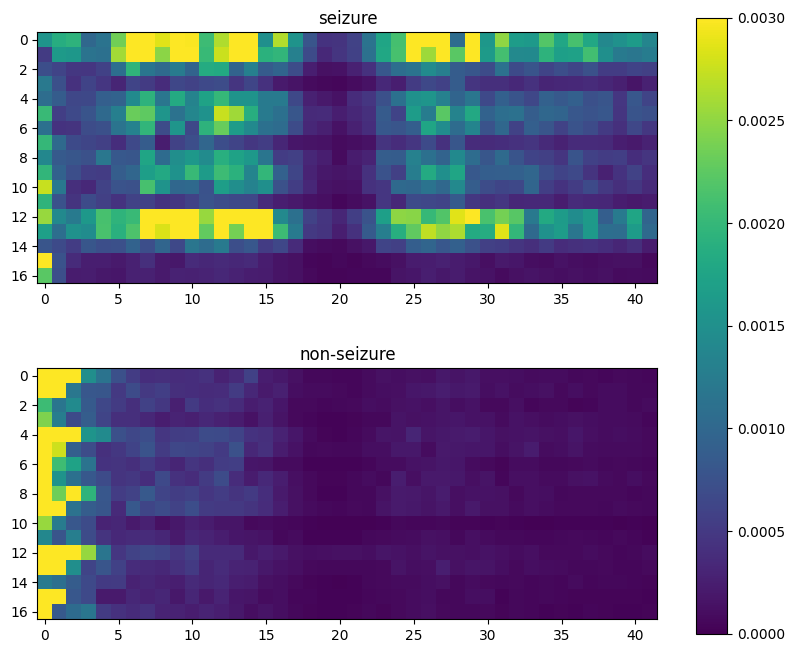

In [5]:
# ── Fourier transform image: seizure vs non-seizure heatmap ──────────────────
def get_reduced_freq_single(channel_fft, batch_size, sampling_rate):
    """Reduce FFT bins for a single channel."""
    layer = []
    batch = []
    for i in channel_fft[0:(sampling_rate*40)+2]:
        batch.append(i)
        if len(batch) == batch_size:
            layer.append(sum(batch) / batch_size)
            batch = []
    return layer

# Build the 17×94 frequency image from raw test data
with open('data/test.pickle', 'rb') as f:
    test_vis = pickle.load(f)

seizure_stft = test_vis[test_vis['seizure'] == 1].iloc[0]['stft']
normal_stft  = test_vis[test_vis['seizure'] == 0].iloc[0]['stft']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
im = axes[0].imshow(seizure_stft, vmin=0, vmax=0.003)
axes[0].set_title("seizure")
axes[1].imshow(normal_stft, vmin=0, vmax=0.003)
axes[1].set_title("non-seizure")
fig.colorbar(im, ax=axes.ravel().tolist())

In [6]:
# ── Load CNN+FFNN model and evaluate ─────────────────────────────────────────
class SeizureDataFull(torch.utils.data.Dataset):
    def __init__(self, x_val, y_val):
        self.freq_features = torch.tensor([[x] for x in x_val.stft], dtype=torch.float32)
        x_no_stft = x_val.drop(columns=['stft'])
        self.time_features = torch.tensor(x_no_stft.values.astype(np.float32))
        self.y_data = torch.tensor(y_val.values.astype(np.float32))
        self.n_samples = x_no_stft.shape[0]
    def __getitem__(self, index):
        return self.time_features[index], self.freq_features[index], self.y_data[index]
    def __len__(self):
        return self.n_samples

class CNNFFNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CNNFFNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 3, 3, padding=1, stride=2)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(3, 9, 3, padding=1, stride=2)
        self.drop = nn.Dropout(0.2)
        self.lin1 = nn.Linear(input_dim, 512)
        self.norm1 = nn.BatchNorm1d(512)
        self.lrelu = nn.LeakyReLU()
        self.lin2 = nn.Linear(512, 512)
        self.norm2 = nn.BatchNorm1d(512)
        self.lin3 = nn.Linear(512, 128)
        self.norm3 = nn.BatchNorm1d(128)
        self.lout = nn.Linear(128, output_dim)

    def forward(self, time, freq):
        freq = self.drop(self.relu(self.conv1(freq)))
        freq = self.relu(self.conv2(freq))
        freq = freq.contiguous().view(freq.shape[0], -1)
        features = torch.cat((freq, time), dim=1)
        y = self.drop(self.lrelu(self.norm1(self.lin1(features))))
        y = self.drop(self.lrelu(self.norm2(self.lin2(y))))
        y = self.lrelu(self.norm3(self.lin3(y)))
        return self.lout(y).squeeze()

cnn_ffnn_model = torch.load("Models/cnnffnn_model.pt", map_location='cpu', weights_only=False)
cnn_ffnn_model.eval()

cnn_test_loader = torch.utils.data.DataLoader(
    SeizureDataFull(X_test, y_test_supervised), batch_size=50, shuffle=False, drop_last=True)

all_pred, all_label = [], []
with torch.no_grad():
    for tf, ff, lb in cnn_test_loader:
        all_pred.append((cnn_ffnn_model(tf, ff) > 0.5).float())
        all_label.append(lb)
y_pred_cnn = torch.cat(all_pred).numpy()
y_true_cnn = torch.cat(all_label).numpy()
m = compute_metrics(y_true_cnn, y_pred_cnn)
m['Model'] = 'CNN+FFNN'
all_results.append(m)
print("CNN+FFNN:", {k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

CNN+FFNN: {'Sensitivity': '0.891', 'Specificity': '0.862', 'Accuracy': '0.877', 'Precision': '0.866', 'F1 Score': '0.879'}


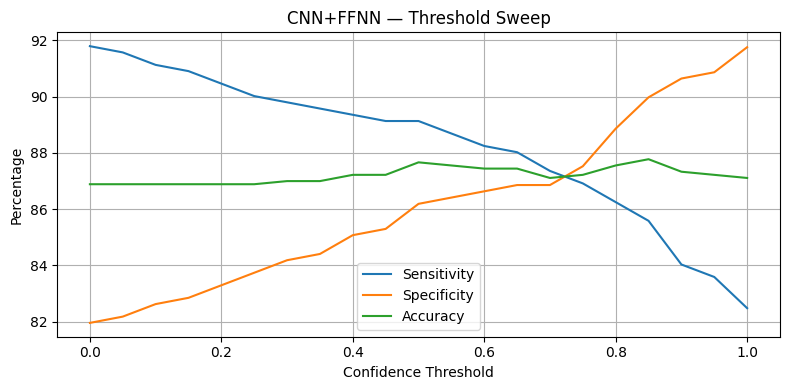

In [7]:
# ── CNN+FFNN: Threshold sweep ────────────────────────────────────────────────
thresholds_cnn = np.arange(0, 1.05, 0.05)
cnn_sens, cnn_spec, cnn_acc = [], [], []

with torch.no_grad():
    all_out, all_lab = [], []
    for tf, ff, lb in cnn_test_loader:
        all_out.append(cnn_ffnn_model(tf, ff))
        all_lab.append(lb)
    all_out = torch.cat(all_out).numpy()
    all_lab = torch.cat(all_lab).numpy()

for t in thresholds_cnn:
    preds = (all_out > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_lab, preds).ravel()
    cnn_sens.append(tp / (tp+fn) * 100 if (tp+fn) else 0)
    cnn_spec.append(tn / (tn+fp) * 100 if (tn+fp) else 0)
    cnn_acc.append((tp+tn) / len(all_lab) * 100)

plt.figure(figsize=(8, 4))
plt.plot(thresholds_cnn, cnn_sens, label='Sensitivity')
plt.plot(thresholds_cnn, cnn_spec, label='Specificity')
plt.plot(thresholds_cnn, cnn_acc, label='Accuracy')
plt.xlabel('Confidence Threshold'); plt.ylabel('Percentage')
plt.title('CNN+FFNN — Threshold Sweep')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

---
## 4. LSTM

**Approach:** Treat seizure detection as a supervised binary classification problem. EEG signals are inherently sequential, so we use LSTM to learn seizure patterns that emerge and evolve across time.

**Architecture:** 

In [8]:
import numpy as np
import glob
from pathlib import Path
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
from eeg_lstm import EEGDataset, EEGLSTM, convert_npz_to_mmap, train_one_epoch, evaluate, evaluate_with_threshold
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
all_paths_train = glob.glob("data_v2/train/*.npz")
all_paths_val   = glob.glob("data_v2/valid/*.npz")
all_paths_test  = glob.glob("data_v2/test/*.npz")

# Run once - skip if already done
convert_npz_to_mmap(all_paths_train, "data_v2/train_mmap")
convert_npz_to_mmap(all_paths_val, "data_v2/valid_mmap")
convert_npz_to_mmap(all_paths_test, "data_v2/test_mmap")

train_dataset = EEGDataset("data_v2/train_mmap")
val_dataset = EEGDataset("data_v2/valid_mmap")
test_dataset = EEGDataset("data_v2/test_mmap")

# Training sampler for 50/50 batches
train_all_labels = np.concatenate([arr[:] for arr in train_dataset.labels])
counts = np.bincount(train_all_labels)

weights = 1.0 / counts
sample_weights = weights[train_all_labels]

train_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=int(counts[1] * 2),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=train_sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

Converting chb01...
Converting chb02...
Converting chb03...
Converting chb04...
Converting chb05...
Converting chb06...
Converting chb10...
Converting chb11...
Converting chb14...
Converting chb15...
Converting chb16...
Converting chb17...
Converting chb18...
Converting chb19...
Converting chb21...
Converting chb22...
Converting chb23...
Converting chb24...
Converting chb13...
Converting chb20...
Converting chb07...
Converting chb08...
Converting chb09...


In [12]:
train_seizure_ratios = []
for epochs, labels in train_loader:
    train_seizure_ratios.append(labels.float().mean().item())

print(f"Mean seizure ratio per batch: {np.mean(train_seizure_ratios):.1%}")  # should be approx 50%
print(f"Batches per epoch: {len(train_loader)}") 

val_seizure_ratios = []
for epochs, labels in val_loader:
    val_seizure_ratios.append(labels.float().mean().item())

print(f"Mean seizure ratio per batch: {np.mean(val_seizure_ratios):.1%}")  # should be approx 50%
print(f"Batches per epoch: {len(val_loader)}") 

test_seizure_ratios = []
for epochs, labels in test_loader:
    test_seizure_ratios.append(labels.float().mean().item())

print(f"Mean seizure ratio per batch: {np.mean(test_seizure_ratios):.1%}")  # should be approx 50%
print(f"Batches per epoch: {len(test_loader)}") 

Mean seizure ratio per batch: 50.2%
Batches per epoch: 481
Mean seizure ratio per batch: 3.4%
Batches per epoch: 388
Mean seizure ratio per batch: 3.5%
Batches per epoch: 676


In [13]:
skip_lstm_training = True

if not skip_lstm_training:
    model  = EEGLSTM().to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
    best_f1 = 0.0

    history = {"loss": [], "accuracy": [], "f1": [], "sensitivity": [], "specificity": []}

    for epoch in range(100):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics           = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        # Track metrics
        for key in history:
            history[key].append(val_metrics[key])

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), "Models/lstm_best.pt")
            print(f"[*] Saved best model (val f1 {best_f1:.3f})")

        print(f"Epoch {epoch+1:02d} | loss {train_loss:.4f} acc {train_acc:.3f} | "
            f"val f1 {val_metrics['f1']:.3f} "
            f"sens {val_metrics['sensitivity']:.3f} "
            f"spec {val_metrics['specificity']:.3f}")

    torch.save(model.state_dict(), "Models/lstm_final.pt")

    # Plot
    epochs = range(1, len(history["f1"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history["sensitivity"], label="Sensitivity")
    plt.plot(epochs, history["specificity"], label="Specificity")
    plt.plot(epochs, history["accuracy"],   label="Accuracy")
    plt.plot(epochs, history["f1"],         label="F1")
    plt.ylabel("Score")
    plt.xlabel("Epoch")
    plt.title("Validation metrics over training")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping LSTM training...")

Skipping LSTM training...


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss().to(device)
model  = EEGLSTM().to(device)

model.load_state_dict(torch.load("Models/lstm_best.pt"))

test_metrics = evaluate(model, test_loader, criterion, device)
print(f"Test Results")
print(f"  Loss:        {test_metrics['loss']:.4f}")
print(f"  Accuracy:    {test_metrics['accuracy']:.3f}")
print(f"  Precision:   {test_metrics['precision']:.3f}")
print(f"  Recall:      {test_metrics['recall']:.3f}")
print(f"  F1:          {test_metrics['f1']:.3f}")
print(f"  Sensitivity: {test_metrics['sensitivity']:.3f}")
print(f"  Specificity: {test_metrics['specificity']:.3f}")

Test Results
  Loss:        0.1402
  Accuracy:    0.970
  Precision:   0.563
  Recall:      0.561
  F1:          0.562
  Sensitivity: 0.561
  Specificity: 0.984


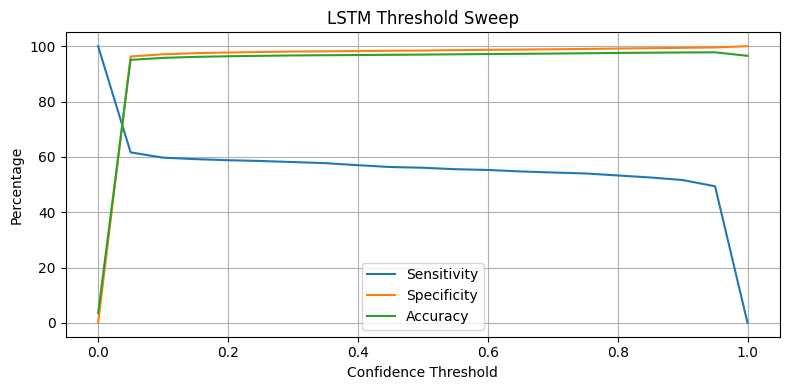

In [15]:
thresholds = np.arange(0, 1.05, 0.05)
sens, spec, acc = [], [], []

with torch.no_grad():
    all_probs, all_lab = [], []
    for x, lb in test_loader:
        x = x.to(device)
        logits = model(x)                                      # (batch, 2)
        probs  = torch.softmax(logits, dim=-1)[:, 1].cpu()     # seizure class probability
        all_probs.append(probs)
        all_lab.append(lb)
    all_probs = torch.cat(all_probs).numpy()
    all_lab   = torch.cat(all_lab).numpy()

for t in thresholds:
    preds = (all_probs > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_lab, preds).ravel()
    sens.append(tp / (tp+fn) * 100 if (tp+fn) else 0)
    spec.append(tn / (tn+fp) * 100 if (tn+fp) else 0)
    acc.append((tp+tn) / len(all_lab) * 100)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, sens, label='Sensitivity')
plt.plot(thresholds, spec, label='Specificity')
plt.plot(thresholds, acc,  label='Accuracy')
plt.xlabel('Confidence Threshold'); plt.ylabel('Percentage')
plt.title('LSTM Threshold Sweep')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [16]:
# maximize Youden's J (sensitivity + specificity - 1)
j_scores = [s/100 + p/100 - 1 for s, p in zip(sens, spec)]
best_threshold = thresholds[np.argmax(j_scores)]

test_metrics_threshold = evaluate_with_threshold(model, test_loader, criterion, device, threshold=best_threshold)
print(f"Test results at optimal threshold {best_threshold:.2f}")
print(f"  Loss:        {test_metrics_threshold['loss']:.4f}")
print(f"  Accuracy:    {test_metrics_threshold['accuracy']:.3f}")
print(f"  Precision:   {test_metrics_threshold['precision']:.3f}")
print(f"  Recall:      {test_metrics_threshold['recall']:.3f}")
print(f"  F1:          {test_metrics_threshold['f1']:.3f}")
print(f"  Sensitivity: {test_metrics_threshold['sensitivity']:.3f}")
print(f"  Specificity: {test_metrics_threshold['specificity']:.3f}")

Test results at optimal threshold 0.05
  Loss:        0.1402
  Accuracy:    0.951
  Precision:   0.373
  Recall:      0.616
  F1:          0.465
  Sensitivity: 0.616
  Specificity: 0.963


In [18]:
lstm_metrics = {
    'Sensitivity': test_metrics_threshold['sensitivity'],
    'Specificity': test_metrics_threshold['specificity'],
    'Accuracy':    test_metrics_threshold['accuracy'],
    'Precision':   test_metrics_threshold['precision'],
    'F1 Score':    test_metrics_threshold['f1'],
}
lstm_metrics['Model'] = 'LSTM'
all_results.append(lstm_metrics)

---
## 5. Conv1D Autoencoder — First Attempt (`model.ipynb`)

**Approach:** Train only on non-seizure epochs → seizure epochs produce higher
reconstruction error → threshold-based detection.

**Architecture:** 4-layer Conv1D, bottleneck 32ch × 32 = 1,024 values (~8.5:1 compression).

**Problem:** Model reconstructed seizures *better* than normal EEG (seizure MAE < normal MAE).
Non-seizure data is more diverse (multiple brain states, artifacts), while seizures
have simpler rhythmic patterns. Bottleneck was too large — model learned to copy.

In [19]:
# ── Autoencoder v1 architecture ───────────────────────────────────────────────
class AutoencoderV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv1d(17,  32,  kernel_size=4, stride=2, padding=1)
        self.bn1  = nn.BatchNorm1d(32)
        self.enc2 = nn.Conv1d(32,  64,  kernel_size=4, stride=2, padding=1)
        self.bn2  = nn.BatchNorm1d(64)
        self.enc3 = nn.Conv1d(64,  128, kernel_size=4, stride=2, padding=1)
        self.bn3  = nn.BatchNorm1d(128)
        self.enc4 = nn.Conv1d(128, 32,  kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.ConvTranspose1d(32,  128, kernel_size=4, stride=2, padding=1)
        self.bn4  = nn.BatchNorm1d(128)
        self.dec2 = nn.ConvTranspose1d(128, 64,  kernel_size=4, stride=2, padding=1)
        self.bn5  = nn.BatchNorm1d(64)
        self.dec3 = nn.ConvTranspose1d(64,  32,  kernel_size=4, stride=2, padding=1)
        self.bn6  = nn.BatchNorm1d(32)
        self.dec4 = nn.ConvTranspose1d(32,  17,  kernel_size=4, stride=2, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        z = self.relu(self.bn1(self.enc1(x)))
        z = self.relu(self.bn2(self.enc2(z)))
        z = self.relu(self.bn3(self.enc3(z)))
        z = self.enc4(z)
        out = self.relu(self.bn4(self.dec1(z)))
        out = self.relu(self.bn5(self.dec2(out)))
        out = self.relu(self.bn6(self.dec3(out)))
        out = self.dec4(out)
        return out

ae_v1 = AutoencoderV1().to(DEVICE)
ae_v1.load_state_dict(torch.load("Models/conv_autoencoder_final.pt", map_location=DEVICE))
ae_v1.eval()
print(ae_v1)
print(f"\nParameters: {sum(p.numel() for p in ae_v1.parameters()):,}")
print(f"Bottleneck: 32 × 32 = 1,024 values (compression ~8.5:1)")

AutoencoderV1(
  (enc1): Conv1d(17, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc2): Conv1d(32, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc3): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc4): Conv1d(128, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (dec1): ConvTranspose1d(32, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec2): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec3): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn6): BatchNor

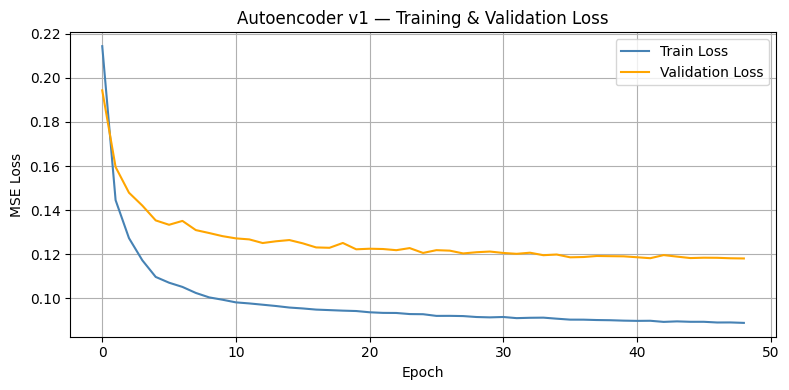

In [20]:
# ── v1 Training history ──────────────────────────────────────────────────────
v1_ckpt_path = "Models/autoencoders_checkpoint.pt"
if os.path.exists(v1_ckpt_path):
    v1_ckpt = torch.load(v1_ckpt_path, map_location='cpu')
    v1_train_hist = v1_ckpt.get('train_history', [])
    v1_val_hist = v1_ckpt.get('val_history', [])
    if v1_train_hist:
        plt.figure(figsize=(8, 4))
        plt.plot(v1_train_hist, label='Train Loss', color='steelblue')
        if v1_val_hist:
            plt.plot(v1_val_hist, label='Validation Loss', color='orange')
        plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
        plt.title('Autoencoder v1 — Training & Validation Loss')
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

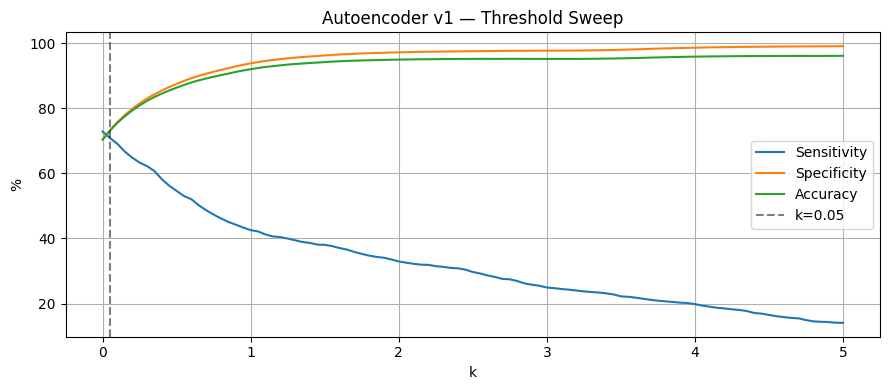

v1 — threshold: 0.1938 (k=0.05)
{'Sensitivity': '0.708', 'Specificity': '0.732', 'Accuracy': '0.732', 'Precision': '0.087', 'F1 Score': '0.156'}


In [21]:
# ── v1 Threshold sweep ───────────────────────────────────────────────────────
with open('Models/conv_autoencoder_threshold.json') as f:
    v1_cfg = json.load(f)
v1_threshold = v1_cfg['threshold']
v1_best_k = v1_cfg.get('k', 0.0)

v1_test_files = sorted(glob.glob('data_v2/test/*.npz'))
v1_train_files = sorted(glob.glob('data_v2/train/*.npz'))

v1_train_maes = []
with torch.no_grad():
    for path in v1_train_files:
        with np.load(path) as d:
            X = d['epochs'][d['labels'] == 0]
        for i in range(0, len(X), 256):
            batch = torch.tensor(X[i:i+256], dtype=torch.float32).to(DEVICE)
            recon = ae_v1(batch)
            v1_train_maes.append(torch.mean(torch.abs(recon - batch), dim=(1, 2)).cpu())
v1_train_mae = torch.cat(v1_train_maes)

v1_test_maes, v1_labels = [], []
with torch.no_grad():
    for path in v1_test_files:
        with np.load(path) as d:
            X, y = d['epochs'], d['labels']
        for i in range(0, len(X), 256):
            batch = torch.tensor(X[i:i+256], dtype=torch.float32).to(DEVICE)
            recon = ae_v1(batch)
            v1_test_maes.append(torch.mean(torch.abs(recon - batch), dim=(1, 2)).cpu())
        v1_labels.extend(y)
v1_test_mae = torch.cat(v1_test_maes)
v1_y_test = np.array(v1_labels)

mean_v1, std_v1 = v1_train_mae.mean().item(), v1_train_mae.std().item()
v1_sweep = []
for k in np.arange(0.0, 5.01, 0.05):
    t = mean_v1 + k * std_v1
    preds = (v1_test_mae.numpy() > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(v1_y_test, preds).ravel()
    v1_sweep.append((k, tp/(tp+fn)*100 if (tp+fn) else 0, tn/(tn+fp)*100 if (tn+fp) else 0, (tp+tn)/len(v1_y_test)*100))

ks, sens_l, spec_l, acc_l = zip(*v1_sweep)
plt.figure(figsize=(9, 4))
plt.plot(ks, sens_l, label='Sensitivity')
plt.plot(ks, spec_l, label='Specificity')
plt.plot(ks, acc_l, label='Accuracy')
plt.axvline(v1_best_k, color='k', linestyle='--', alpha=0.5, label=f'k={v1_best_k:.2f}')
plt.xlabel('k'); plt.ylabel('%'); plt.title('Autoencoder v1 — Threshold Sweep')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

v1_preds = (v1_test_mae.numpy() > v1_threshold).astype(int)
m = compute_metrics(v1_y_test, v1_preds)
m['Model'] = 'Autoencoder v1'
all_results.append(m)
print(f"v1 — threshold: {v1_threshold:.4f} (k={v1_best_k:.2f})")
print({k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

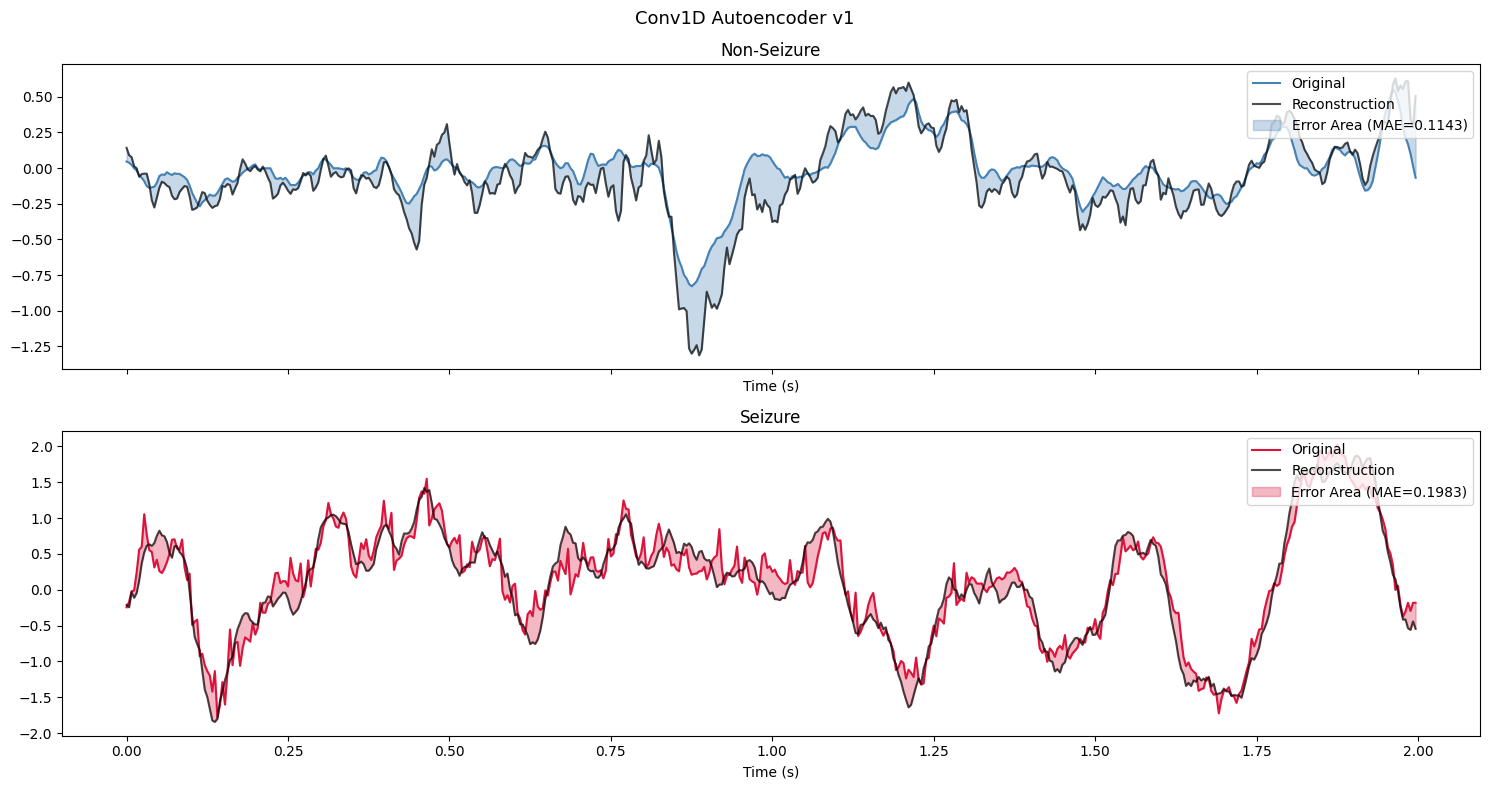

In [22]:
# ── v1 Reconstruction plot (stacked with error area) ─────────────────────────
with np.load(v1_test_files[0]) as d:
    X_vis, y_vis = d['epochs'], d['labels']

normal_in = torch.tensor(X_vis[y_vis == 0][3:4], dtype=torch.float32).to(DEVICE)
seizure_in = torch.tensor(X_vis[y_vis == 1][3:4], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    normal_out = ae_v1(normal_in)
    seizure_out = ae_v1(seizure_in)
normal_in, seizure_in = normal_in.cpu(), seizure_in.cpu()
normal_out, seizure_out = normal_out.cpu(), seizure_out.cpu()

t_axis = np.arange(512) / 256.0
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Conv1D Autoencoder v1', fontsize=13)

def plot_stacked(ax, orig, recon, color, label):
    err = np.abs(recon - orig)
    ax.plot(t_axis, orig, color=color, label='Original')
    ax.plot(t_axis, recon, color='black', alpha=0.7, label='Reconstruction')
    ax.fill_between(t_axis, orig, recon, color=color, alpha=0.3, label=f'Error Area (MAE={err.mean():.4f})')
    ax.set_title(label); ax.set_xlabel('Time (s)'); ax.legend(loc='upper right')

plot_stacked(axes[0], normal_in[0,0].numpy(), normal_out[0,0].numpy(), 'steelblue', 'Non-Seizure')
plot_stacked(axes[1], seizure_in[0,0].numpy(), seizure_out[0,0].numpy(), 'crimson', 'Seizure')
plt.tight_layout(); plt.show()

---
## 6. Conv1D Autoencoder v2 — Improved (`autoencoder_model.ipynb`)

### Data: `generate_train_test_v2.py`
Raw EEG epochs (17 channels × 512 samples), z-scored per channel.

**Patient split:** 18 train / 2 valid (chb13, chb20) / 3 test (chb07, chb08, chb09)

### Improvements over v1:
| Change | v1 | v2 |
|--------|----|----|
| Bottleneck | 32ch × 32 = 1,024 | **8ch × 32 = 256** (~34:1) |
| Dropout | None | **0.2** in encoder |
| L1 penalty | None | **1e-4 × mean(\|z\|)** on bottleneck |
| Validation | Used test set | **Separate valid split** |
| Fine-tuning | None | **Patient-specific calibration** |

In [23]:
# ── Autoencoder v2 architecture + load ────────────────────────────────────────
class Conv1DAutoencoderV2(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.enc1 = nn.Conv1d(17,  32,  kernel_size=4, stride=2, padding=1)
        self.bn1  = nn.BatchNorm1d(32)
        self.enc2 = nn.Conv1d(32,  64,  kernel_size=4, stride=2, padding=1)
        self.bn2  = nn.BatchNorm1d(64)
        self.enc3 = nn.Conv1d(64,  128, kernel_size=4, stride=2, padding=1)
        self.bn3  = nn.BatchNorm1d(128)
        self.enc4 = nn.Conv1d(128, 8,   kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.ConvTranspose1d(8,   128, kernel_size=4, stride=2, padding=1)
        self.bn4  = nn.BatchNorm1d(128)
        self.dec2 = nn.ConvTranspose1d(128, 64,  kernel_size=4, stride=2, padding=1)
        self.bn5  = nn.BatchNorm1d(64)
        self.dec3 = nn.ConvTranspose1d(64,  32,  kernel_size=4, stride=2, padding=1)
        self.bn6  = nn.BatchNorm1d(32)
        self.dec4 = nn.ConvTranspose1d(32,  17,  kernel_size=4, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.drop(self.relu(self.bn1(self.enc1(x))))
        z = self.drop(self.relu(self.bn2(self.enc2(z))))
        z = self.drop(self.relu(self.bn3(self.enc3(z))))
        z = self.enc4(z)
        out = self.relu(self.bn4(self.dec1(z)))
        out = self.relu(self.bn5(self.dec2(out)))
        out = self.relu(self.bn6(self.dec3(out)))
        out = self.dec4(out)
        return out, z

ae_v2 = Conv1DAutoencoderV2(dropout=0.2).to(DEVICE)
ae_v2.load_state_dict(torch.load("Models/ae_v2_final.pt", map_location=DEVICE))
ae_v2.eval()
print(f"Parameters: {sum(p.numel() for p in ae_v2.parameters()):,}")
print(f"Bottleneck: 8 × 32 = 256 values (compression ~34:1)")

Parameters: 95,833
Bottleneck: 8 × 32 = 256 values (compression ~34:1)


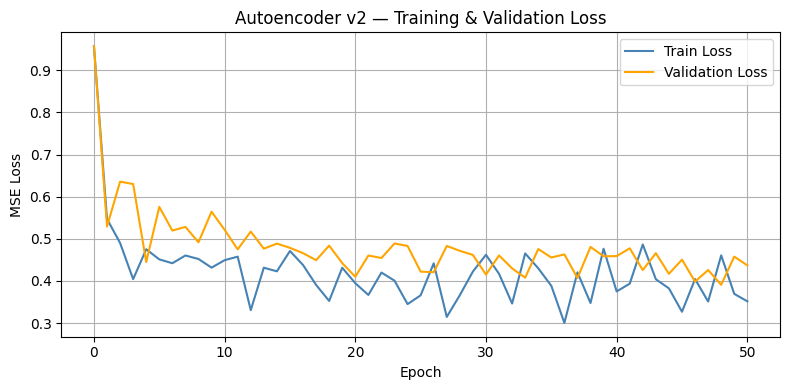

In [24]:
# ── v2 Training history ──────────────────────────────────────────────────────
v2_ckpt_path = "Models/ae_v2_checkpoint.pt"
if os.path.exists(v2_ckpt_path):
    v2_ckpt = torch.load(v2_ckpt_path, map_location='cpu')
    v2_train_hist = v2_ckpt.get('train_hist', [])
    v2_val_hist = v2_ckpt.get('val_hist', [])
    if v2_train_hist:
        plt.figure(figsize=(8, 4))
        plt.plot(v2_train_hist, label='Train Loss', color='steelblue')
        plt.plot(v2_val_hist, label='Validation Loss', color='orange')
        plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
        plt.title('Autoencoder v2 — Training & Validation Loss')
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Train normal — mean MAE: 0.411213 | std: 0.203985
Optimal k=0.30  |  Threshold=0.472408


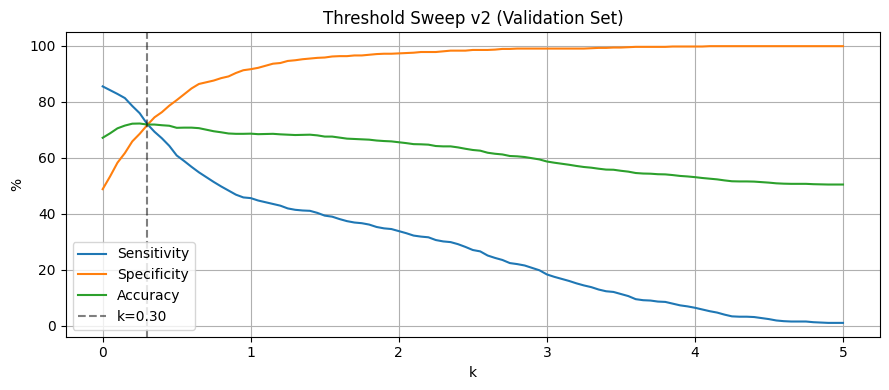

{'Sensitivity': '0.917', 'Specificity': '0.781', 'Accuracy': '0.849', 'Precision': '0.807', 'F1 Score': '0.859'}


In [25]:
# ── v2 Threshold sweep (using validation set) ────────────────────────────────
with open('Models/ae_v2_threshold.json') as f:
    v2_cfg = json.load(f)
v2_threshold = v2_cfg['threshold']
v2_best_k = v2_cfg['k']

v2_train_files = sorted(glob.glob('data_v2/train/*.npz'))
v2_val_files = sorted(glob.glob('data_v2/valid/*.npz'))
v2_test_files = sorted(glob.glob('data_v2/test/*.npz'))

def collect_mae(model, file_list, both_classes=False):
    """Returns (mae_tensor, labels_array)."""
    model.eval()
    maes, labels = [], []
    with torch.no_grad():
        for path in file_list:
            with np.load(path) as d:
                X, y = d['epochs'], d['labels']
            if not both_classes:
                X, y = X[y == 0], y[y == 0]
            for i in range(0, len(X), 256):
                batch = torch.tensor(X[i:i+256], dtype=torch.float32).to(DEVICE)
                recon, _ = model(batch)
                maes.append(torch.mean(torch.abs(recon - batch), dim=(1, 2)).cpu())
            labels.extend(y)
    
    maes = torch.cat(maes)
    labels = np.array(labels)
    
    if both_classes:
        idx_0 = np.where(labels == 0)[0]
        idx_1 = np.where(labels == 1)[0]
        min_len = min(len(idx_0), len(idx_1))
        
        # Subsample to match the length of the minority class
        idx_0 = np.random.choice(idx_0, min_len, replace=False)
        idx_1 = np.random.choice(idx_1, min_len, replace=False)
        
        bal_idx = np.concatenate([idx_0, idx_1])
        maes, labels = maes[bal_idx], labels[bal_idx]

    return maes, labels

train_mae, _ = collect_mae(ae_v2, v2_train_files, both_classes=False)
val_mae, y_val = collect_mae(ae_v2, v2_val_files, both_classes=True)

mean_mae = train_mae.mean().item()
std_mae = train_mae.std().item()
print(f"Train normal — mean MAE: {mean_mae:.6f} | std: {std_mae:.6f}")

best_k, best_diff = 1.0, float('inf')
sweep = []
for k in np.arange(0.0, 5.01, 0.05):
    t = mean_mae + k * std_mae
    preds = (val_mae.numpy() > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    sens = tp / (tp+fn) * 100 if (tp+fn) > 0 else 0
    spec = tn / (tn+fp) * 100 if (tn+fp) > 0 else 0
    acc = (tp+tn) / len(y_val) * 100
    sweep.append((k, t, sens, spec, acc))   
    if abs(sens - spec) < best_diff:
        best_diff, best_k = abs(sens - spec), k

v2_threshold = mean_mae + best_k * std_mae
print(f"Optimal k={best_k:.2f}  |  Threshold={v2_threshold:.6f}")

ks, sens_l, spec_l, acc_l = zip(*[(r[0], r[2], r[3], r[4]) for r in sweep])
plt.figure(figsize=(9, 4))
plt.plot(ks, sens_l, label='Sensitivity')
plt.plot(ks, spec_l, label='Specificity')
plt.plot(ks, acc_l, label='Accuracy')
plt.axvline(best_k, color='k', linestyle='--', alpha=0.5, label=f'k={best_k:.2f}')
plt.xlabel('k'); plt.ylabel('%'); plt.title('Threshold Sweep v2 (Validation Set)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Evaluate on TEST set
v2_test_mae, v2_y_test = collect_mae(ae_v2, v2_test_files, both_classes=True)
v2_preds = (v2_test_mae.numpy() > v2_threshold).astype(int)
m = compute_metrics(v2_y_test, v2_preds)
m['Model'] = 'Autoencoder v2 (global)'
all_results.append(m)
print({k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

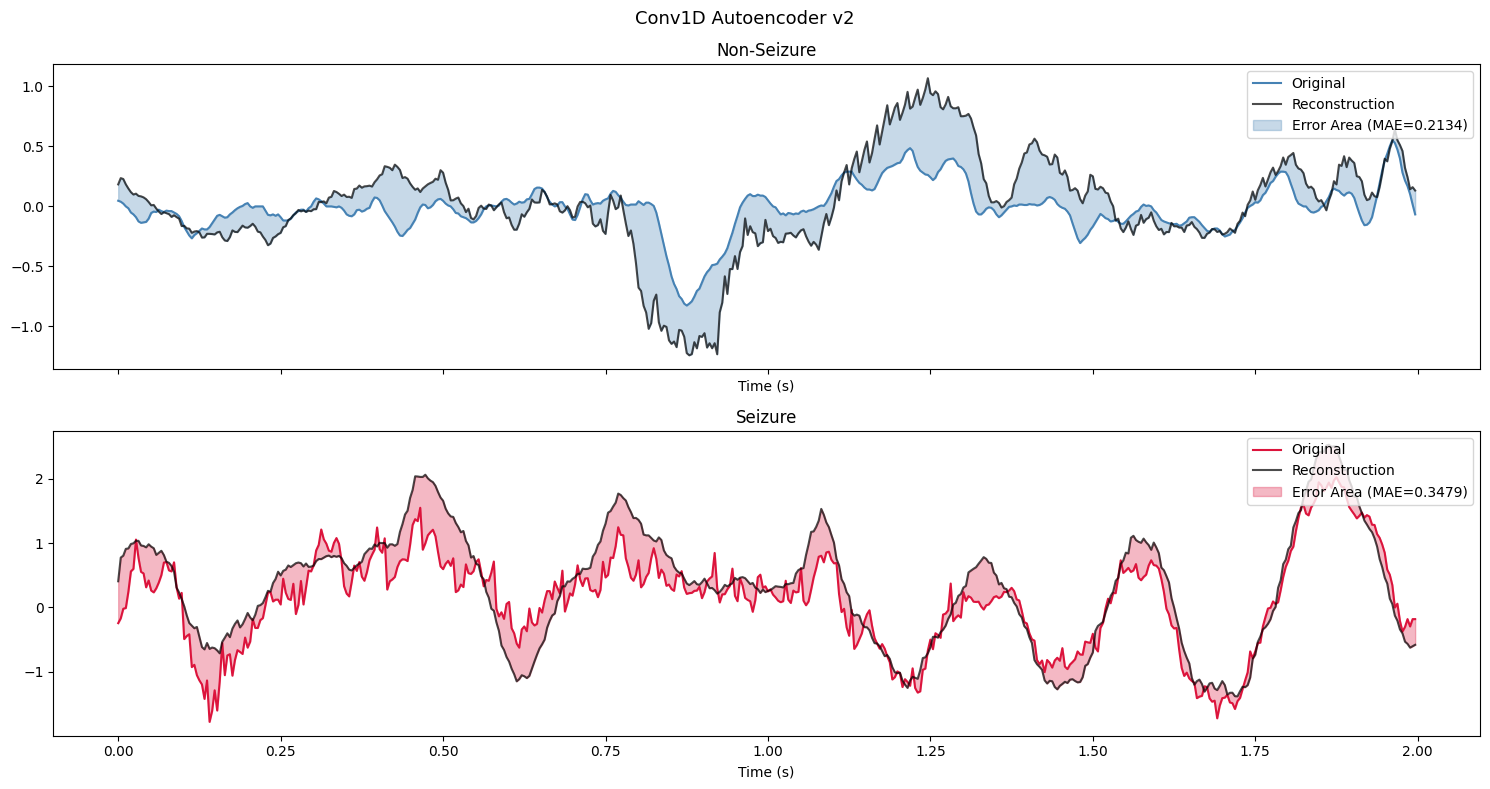

In [26]:
# ── v2 Reconstruction plot (stacked) ─────────────────────────────────────────
with np.load(v2_test_files[0]) as d:
    X_vis2, y_vis2 = d['epochs'], d['labels']

normal_in = torch.tensor(X_vis2[y_vis2 == 0][3:4], dtype=torch.float32).to(DEVICE)
seizure_in = torch.tensor(X_vis2[y_vis2 == 1][3:4], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    normal_out, _ = ae_v2(normal_in)
    seizure_out, _ = ae_v2(seizure_in)
normal_in, seizure_in = normal_in.cpu(), seizure_in.cpu()
normal_out, seizure_out = normal_out.cpu(), seizure_out.cpu()

t_axis = np.arange(512) / 256.0
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Conv1D Autoencoder v2', fontsize=13)
plot_stacked(axes[0], normal_in[0,0].numpy(), normal_out[0,0].numpy(), 'steelblue', 'Non-Seizure')
plot_stacked(axes[1], seizure_in[0,0].numpy(), seizure_out[0,0].numpy(), 'crimson', 'Seizure')
plt.tight_layout(); plt.show()

### Patient-Specific Fine-Tuning (v2)

In [27]:
# ── Fine-tune helper + v2 per-patient eval ───────────────────────────────────
L1_LAMBDA = 1e-4

def finetune_patient(base_model, normal_epochs, lr=1e-4, epochs=10, batch_size=32):
    pt_model = copy.deepcopy(base_model)
    pt_optim = torch.optim.Adam(pt_model.parameters(), lr=lr, weight_decay=1e-5)
    t = torch.tensor(normal_epochs, dtype=torch.float32)
    loader = DataLoader(TensorDataset(t), batch_size=batch_size, shuffle=True)
    criterion = nn.MSELoss()
    pt_model.train()
    for _ in range(epochs):
        for (batch,) in loader:
            batch = batch.to(DEVICE, non_blocking=True)
            recon, z = pt_model(batch)
            loss = criterion(recon, batch) + L1_LAMBDA * z.abs().mean()
            pt_optim.zero_grad(); loss.backward(); pt_optim.step()
    pt_model.eval()
    return pt_model

def patient_mae(mdl, X):
    maes = []
    with torch.no_grad():
        for i in range(0, len(X), 256):
            batch = torch.tensor(X[i:i+256], dtype=torch.float32).to(DEVICE)
            recon, _ = mdl(batch)
            maes.append(torch.mean(torch.abs(recon - batch), dim=(1, 2)).cpu())
    return torch.cat(maes).numpy()

v2_ft_metrics = []
for path in v2_test_files:
    pid = os.path.basename(path).replace('.npz', '')
    with np.load(path) as d:
        X, y = d['epochs'], d['labels']

    # Fine-tune and set threshold using ALL normal data
    X_normal = X[y == 0]
    ft_model = finetune_patient(ae_v2, X_normal)
    ft_normal_mae = patient_mae(ft_model, X_normal)
    pt_threshold = ft_normal_mae.mean() + best_k * ft_normal_mae.std()

    # Balance classes for evaluation
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    min_len = min(len(idx_0), len(idx_1))

    idx_0 = np.random.choice(idx_0, min_len, replace=False)
    idx_1 = np.random.choice(idx_1, min_len, replace=False)
    bal_idx = np.concatenate([idx_0, idx_1])
    X_eval, y_eval = X[bal_idx], y[bal_idx]

    ft_preds = (patient_mae(ft_model, X_eval) > pt_threshold).astype(int)
    pm = compute_metrics(y_eval, ft_preds)
    v2_ft_metrics.append(pm)
    print(f"  {pid}: Acc={pm['Accuracy']:.3f} Sens={pm['Sensitivity']:.3f} Spec={pm['Specificity']:.3f}")

v2_ft_avg = {k: np.mean([m[k] for m in v2_ft_metrics]) for k in v2_ft_metrics[0]}
v2_ft_avg['Model'] = 'Autoencoder v2 (fine-tuned)'
all_results.append(v2_ft_avg)
print(f"\nv2 fine-tuned avg: Acc={v2_ft_avg['Accuracy']:.3f} Sens={v2_ft_avg['Sensitivity']:.3f} Spec={v2_ft_avg['Specificity']:.3f}")

  chb07: Acc=0.890 Sens=0.997 Spec=0.783
  chb08: Acc=0.845 Sens=0.852 Spec=0.837
  chb09: Acc=0.907 Sens=0.985 Spec=0.828

v2 fine-tuned avg: Acc=0.880 Sens=0.945 Spec=0.816


---
## 7. Conv1D Autoencoder v3 — 6-Second Epochs

Same as v2 but **6-second epochs** (1536 samples) and **3-second overlap** for seizures.

| Parameter | v2 | v3 |
|-----------|----|----|
| Epoch duration | 2 s | **6 s** |
| Samples/epoch | 512 | **1536** |
| Overlap (seizure) | 1 s | **3 s** |
| Bottleneck | 8 × 32 = 256 | **8 × 96 = 768** |
| Compression ratio | ~34:1 | ~34:1 |

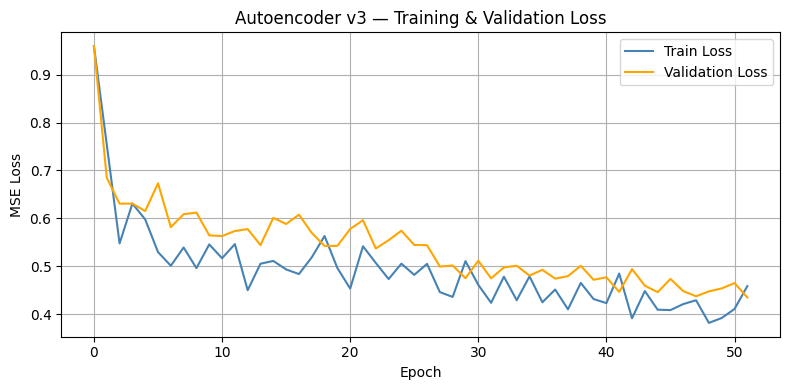

In [28]:
# ── Load v3 + training history ────────────────────────────────────────────────
ae_v3 = Conv1DAutoencoderV2(dropout=0.2).to(DEVICE)
ae_v3.load_state_dict(torch.load("Models/ae_v3_final.pt", map_location=DEVICE))
ae_v3.eval()

v3_ckpt_path = "Models/ae_v3_checkpoint.pt"
if os.path.exists(v3_ckpt_path):
    v3_ckpt = torch.load(v3_ckpt_path, map_location='cpu')
    v3_train_hist = v3_ckpt.get('train_hist', [])
    v3_val_hist = v3_ckpt.get('val_hist', [])
    if v3_train_hist:
        plt.figure(figsize=(8, 4))
        plt.plot(v3_train_hist, label='Train Loss', color='steelblue')
        plt.plot(v3_val_hist, label='Validation Loss', color='orange')
        plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
        plt.title('Autoencoder v3 — Training & Validation Loss')
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Train normal — mean MAE: 0.410378 | std: 0.190312
Optimal k=0.40  |  Threshold=0.486503


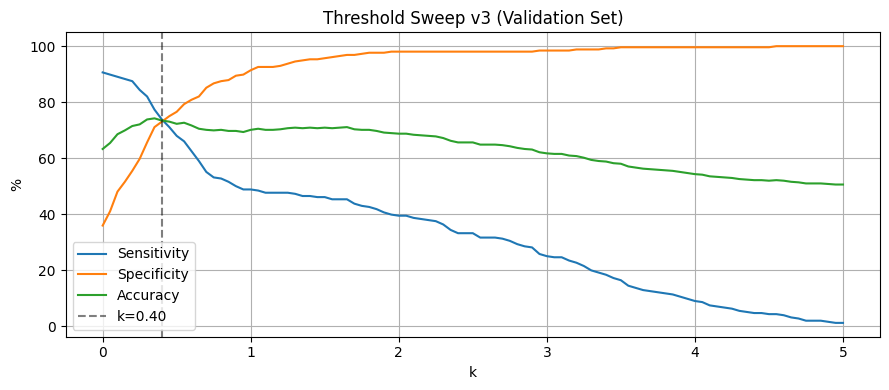

{'Sensitivity': '0.935', 'Specificity': '0.843', 'Accuracy': '0.889', 'Precision': '0.857', 'F1 Score': '0.894'}


In [29]:
# ── v3 Threshold sweep (validation set) ──────────────────────────────────────
v3_train_files = sorted(glob.glob('data_v3/train/*.npz'))
v3_val_files = sorted(glob.glob('data_v3/valid/*.npz'))
v3_test_files = sorted(glob.glob('data_v3/test/*.npz'))

train_mae, _ = collect_mae(ae_v3, v3_train_files, both_classes=False)
val_mae, y_val = collect_mae(ae_v3, v3_val_files, both_classes=True)

mean_mae = train_mae.mean().item()
std_mae = train_mae.std().item()
print(f"Train normal — mean MAE: {mean_mae:.6f} | std: {std_mae:.6f}")

best_k_v3, best_diff = 1.0, float('inf')
sweep = []
for k in np.arange(0.0, 5.01, 0.05):
    t = mean_mae + k * std_mae
    preds = (val_mae.numpy() > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    sens = tp / (tp+fn) * 100 if (tp+fn) > 0 else 0
    spec = tn / (tn+fp) * 100 if (tn+fp) > 0 else 0
    acc = (tp+tn) / len(y_val) * 100
    sweep.append((k, t, sens, spec, acc))
    if abs(sens - spec) < best_diff:
        best_diff, best_k_v3 = abs(sens - spec), k

v3_threshold = mean_mae + best_k_v3 * std_mae
print(f"Optimal k={best_k_v3:.2f}  |  Threshold={v3_threshold:.6f}")

with open('Models/ae_v3_threshold.json', 'w') as f:
    json.dump({'threshold': v3_threshold, 'k': float(best_k_v3),
               'mean_mae': mean_mae, 'std_mae': std_mae}, f, indent=2)

ks, sens_l, spec_l, acc_l = zip(*[(r[0], r[2], r[3], r[4]) for r in sweep])
plt.figure(figsize=(9, 4))
plt.plot(ks, sens_l, label='Sensitivity')
plt.plot(ks, spec_l, label='Specificity')
plt.plot(ks, acc_l, label='Accuracy')
plt.axvline(best_k_v3, color='k', linestyle='--', alpha=0.5, label=f'k={best_k_v3:.2f}')
plt.xlabel('k'); plt.ylabel('%'); plt.title('Threshold Sweep v3 (Validation Set)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

v3_test_mae, v3_y_test = collect_mae(ae_v3, v3_test_files, both_classes=True)
v3_preds = (v3_test_mae.numpy() > v3_threshold).astype(int)
m = compute_metrics(v3_y_test, v3_preds)
m['Model'] = 'Autoencoder v3 (global)'
all_results.append(m)
print({k: f"{v:.3f}" for k, v in m.items() if k != 'Model'})

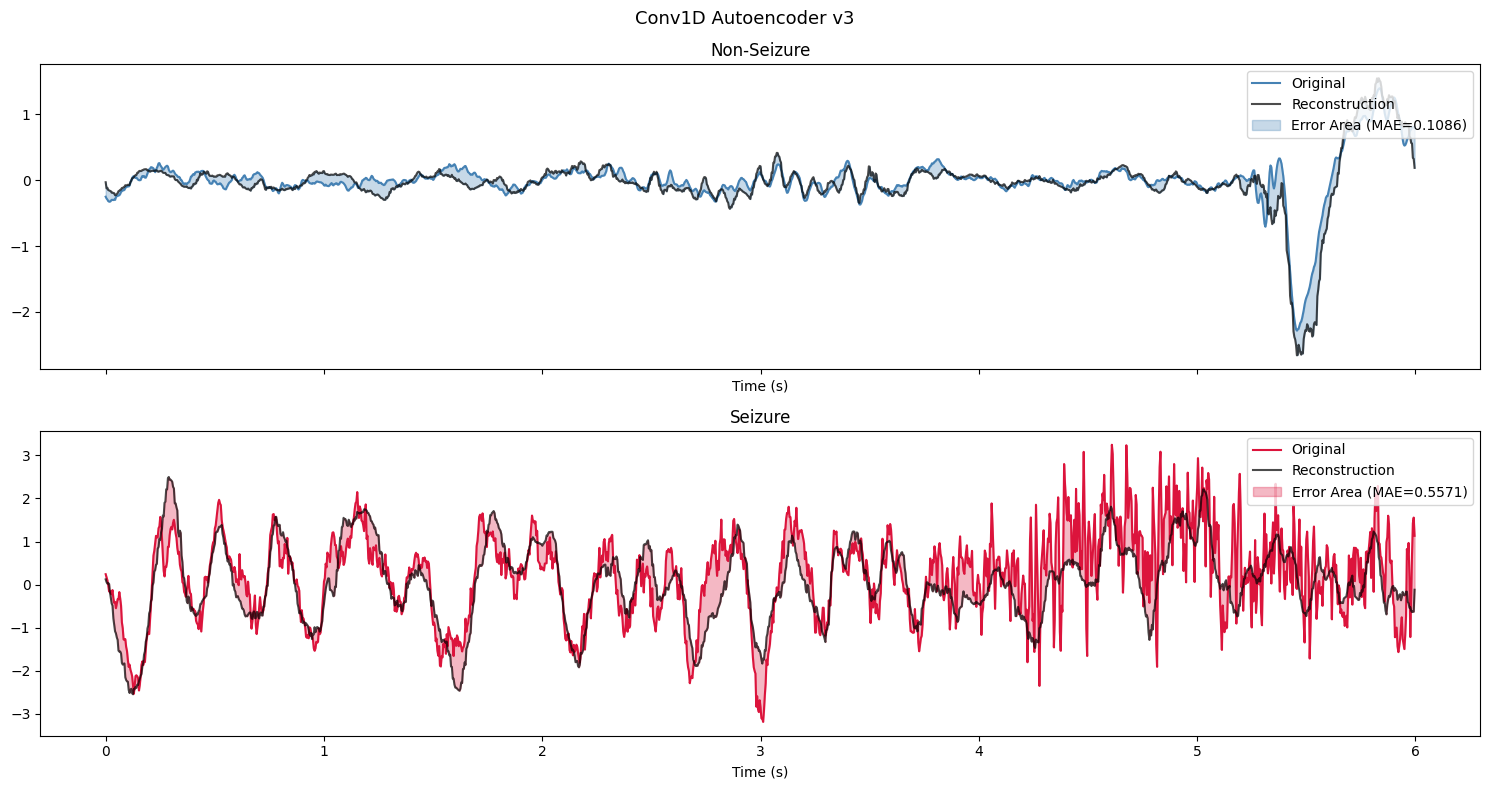

In [30]:
# ── v3 Reconstruction plot (stacked, 6s) ─────────────────────────────────────
with np.load(v3_test_files[0]) as d:
    X_vis3, y_vis3 = d['epochs'], d['labels']

normal_in = torch.tensor(X_vis3[y_vis3 == 0][3:4], dtype=torch.float32).to(DEVICE)
seizure_in = torch.tensor(X_vis3[y_vis3 == 1][3:4], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    normal_out, _ = ae_v3(normal_in)
    seizure_out, _ = ae_v3(seizure_in)
normal_in, seizure_in = normal_in.cpu(), seizure_in.cpu()
normal_out, seizure_out = normal_out.cpu(), seizure_out.cpu()

t_axis_v3 = np.arange(1536) / 256.0
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Conv1D Autoencoder v3', fontsize=13)

def plot_stacked_v3(ax, orig, recon, color, label):
    err = np.abs(recon - orig)
    ax.plot(t_axis_v3, orig, color=color, label='Original')
    ax.plot(t_axis_v3, recon, color='black', alpha=0.7, label='Reconstruction')
    ax.fill_between(t_axis_v3, orig, recon, color=color, alpha=0.3, label=f'Error Area (MAE={err.mean():.4f})')
    ax.set_title(label); ax.set_xlabel('Time (s)'); ax.legend(loc='upper right')

plot_stacked_v3(axes[0], normal_in[0,0].numpy(), normal_out[0,0].numpy(), 'steelblue', 'Non-Seizure')
plot_stacked_v3(axes[1], seizure_in[0,0].numpy(), seizure_out[0,0].numpy(), 'crimson', 'Seizure')
plt.tight_layout(); plt.show()

In [31]:
# ── v3 Fine-tune per patient ──────────────────────────────────────────────────
v3_ft_metrics = []
for path in v3_test_files:
    pid = os.path.basename(path).replace('.npz', '')
    with np.load(path) as d:
        X, y = d['epochs'], d['labels']

    # Fine-tune and set threshold using ALL normal data
    X_normal = X[y == 0]
    ft_model = finetune_patient(ae_v3, X_normal)
    ft_normal_mae = patient_mae(ft_model, X_normal)
    pt_threshold = ft_normal_mae.mean() + best_k_v3 * ft_normal_mae.std()

    # Balance classes for evaluation
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    min_len = min(len(idx_0), len(idx_1))

    idx_0 = np.random.choice(idx_0, min_len, replace=False)
    idx_1 = np.random.choice(idx_1, min_len, replace=False)
    bal_idx = np.concatenate([idx_0, idx_1])
    X_eval, y_eval = X[bal_idx], y[bal_idx]

    ft_preds = (patient_mae(ft_model, X_eval) > pt_threshold).astype(int)
    pm = compute_metrics(y_eval, ft_preds)
    v3_ft_metrics.append(pm)
    print(f"  {pid}: Acc={pm['Accuracy']:.3f} Sens={pm['Sensitivity']:.3f} Spec={pm['Specificity']:.3f}")

v3_ft_avg = {k: np.mean([m[k] for m in v3_ft_metrics]) for k in v3_ft_metrics[0]}
v3_ft_avg['Model'] = 'Autoencoder v3 (fine-tuned)'
all_results.append(v3_ft_avg)
print(f"\nv3 fine-tuned avg: Acc={v3_ft_avg['Accuracy']:.3f} Sens={v3_ft_avg['Sensitivity']:.3f}, Spec={v3_ft_avg['Specificity']:.3f}")

  chb07: Acc=0.894 Sens=1.000 Spec=0.788
  chb08: Acc=0.872 Sens=0.880 Spec=0.863
  chb09: Acc=0.938 Sens=1.000 Spec=0.875

v3 fine-tuned avg: Acc=0.901 Sens=0.960, Spec=0.842


---
## 8. Final Comparison

All metrics computed on the **same 3 test patients** (chb07, chb08, chb09).

> For autoencoders v2/v3 fine-tuned, metrics are the **average across patients**
> after patient-specific calibration. Threshold balanced (sensitivity ≈ specificity)
> so the comparison is fair.

In [32]:
# ── Final comparison ──────────────────────────────────────────────────────────
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index('Model')[['Sensitivity', 'Specificity', 'Accuracy', 'F1 Score']]
df_display = (df_results * 100).round(2)
df_display.columns = [f'{c} (%)' for c in df_display.columns]
df_display = df_display.sort_values(by='F1 Score (%)', ascending=False)

print("=" * 85)
print("  FINAL MODEL COMPARISON — Seizure Detection on CHB-MIT")
print("=" * 85)
display(df_display)

  FINAL MODEL COMPARISON — Seizure Detection on CHB-MIT


,Sensitivity (%),Specificity (%),Accuracy (%),F1 Score (%)
Model,,,,
Autoencoder v3 (fine-tuned),96.00,84.23,90.11,90.61
Autoencoder v3 (global),93.50,84.35,88.92,89.41
Autoencoder v2 (fine-tuned),94.48,81.58,88.03,88.66
CNN+FFNN,89.14,86.19,87.67,87.87
KNN (k=60),88.41,86.70,87.55,87.66
Random Forest,88.41,86.70,87.55,87.66
SVM (linear),87.77,84.12,85.94,86.20
Autoencoder v2 (global),91.72,78.13,84.92,85.88
FFNN,88.47,79.06,83.78,84.53


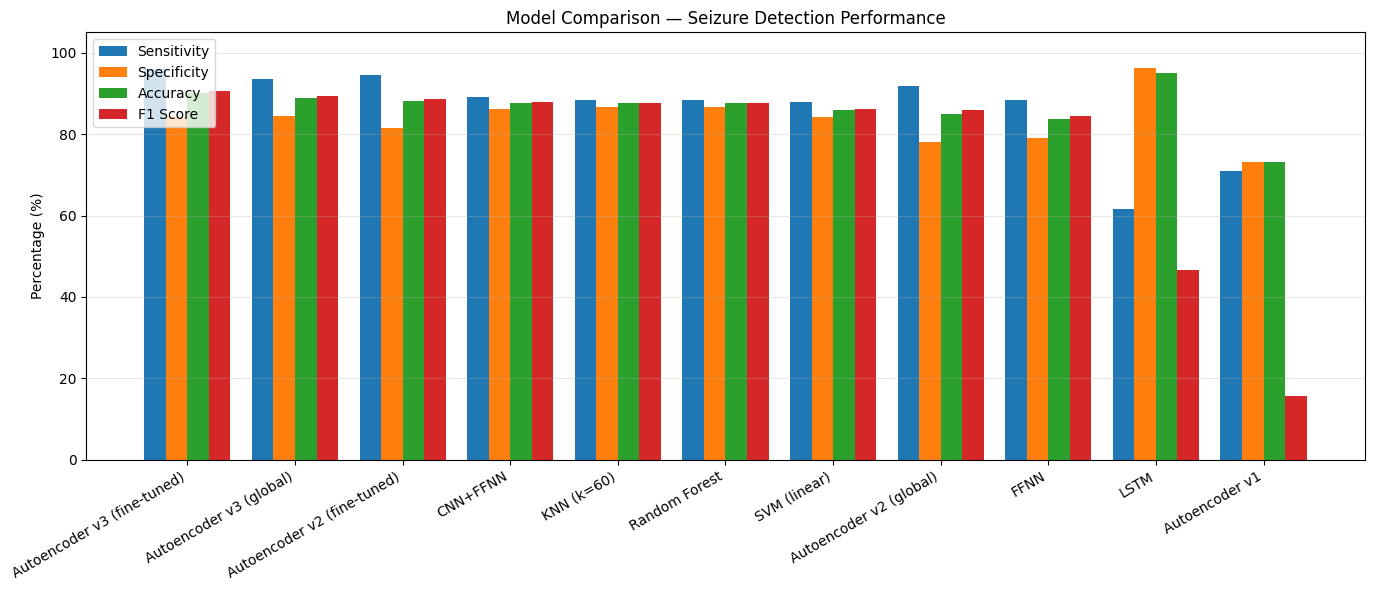

In [33]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
metrics_to_plot = ['Sensitivity (%)', 'Specificity (%)', 'Accuracy (%)', 'F1 Score (%)']
df_plot = df_display[metrics_to_plot]

x = np.arange(len(df_plot))
width = 0.2
for i, col in enumerate(metrics_to_plot):
    ax.bar(x + i*width, df_plot[col], width, label=col.replace(' (%)', ''))

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot.index, rotation=30, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Model Comparison — Seizure Detection Performance')
ax.legend(loc='upper left'); ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()